In [1]:
from utils import *

In [2]:
system = fluxonium_oscillator_system(
    EJ = 3,
    EC = 0.6,
    EL = 0.13,
    Er = 7.2622522,
    g_strength = 0.3,
    qubit_level = 30,
    osc_level = 30,
    # kappa = 0.001,
    products_to_keep=[[ql, ol] for ql in [1,2,3] for ol in range(10) ] \
                    + [[ql, ol] for ql in [0] for ol in range(30) ]
    )


In [3]:
evals = system.qbt.eigenvals(20)
evals[1] + 7.2622522, evals

(8.436811439238546,
 array([-1.21902782,  1.17455924,  1.1837642 ,  1.94950341,  3.74192981,
         4.19109653,  4.99227244,  6.27453091,  7.29164279,  8.18024307,
         8.36014371,  8.63019782,  9.57809098, 10.44350745, 11.15437676,
        11.87278824, 12.72165741, 13.63510834, 14.55339696, 15.48402298]))

In [6]:
tot_time =900
t_stop = 474
tlist = np.linspace(0, tot_time, tot_time)

results = system.run_mesolve_on_driving_osc(
    intial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(i, 0)])) for i in range(4)],
    tlist = tlist,
    osc_decay = False,
    amp = 0.004,
)


# import pickle
# with open('pickles/sesolve_detection_results.pkl', 'wb') as file:
#     pickle.dump(results, file)

# with open('pickles/sesolve_detection_results.pkl', 'rb') as file:
#     results = pickle.load(file)

 Total run time:  22.30s*] Elapsed 22.30s / Remaining 00:00:00:00[          0%           ] Elapsed 0.00s / Remaining 00:00:00:00
 Total run time:  22.58s*] Elapsed 22.58s / Remaining 00:00:00:00
 Total run time:  22.73s*] Elapsed 22.73s / Remaining 00:00:00:00
 Total run time:  24.30s*] Elapsed 24.30s / Remaining 00:00:00:00


 /Users/jiakaiwang/opt/miniconda3/envs/tensorflow/lib/python3.10/site-packages/jax/_src/array.py: 343

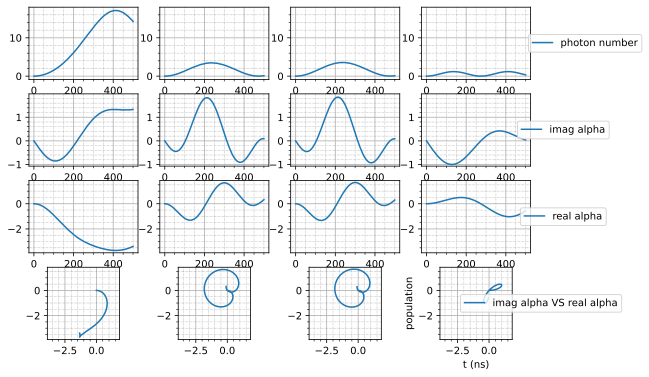

In [7]:
import jax.numpy as jnp
from jax import jit, vmap

def compute_expectation(ket_or_dm, operator):
    # Check if the input is a ket or a density matrix
    if ket_or_dm.shape[-1] == 1:  # Input is a ket
        return (jnp.linalg.multi_dot([jnp.conj(ket_or_dm).T, operator, ket_or_dm]))[0][0]
    else:  # Input is a density matrix
        return jnp.trace(jnp.dot(operator, ket_or_dm))
        
def get_vectorized_compute_expectation_function():
    # Vectorize the function over the kets
    vmapped_function = vmap(compute_expectation, in_axes=(0, None))
    return  jit(vmapped_function)

def plot_population(results,qubit_level,osc_level,product_to_dressed,a,w_d,tlist,fourier=False,fix_ylim = True,plot_only_pn_alpha = False):
    product_states = [(ql,ol) for ql in range(qubit_level) for ol in range(osc_level)]
    idxs = [product_to_dressed[(s1, s2)] for (s1, s2) in product_states]
    tot_dims = qubit_level*osc_level

    nlevels = len(results)


    a_op = jnp.array(a.full())
    pn_op = jnp.array((a.dag()*a).full())

    # Vectorize the function compute_expectation over the kets
    vectorized_compute_expectation = vmap(compute_expectation, in_axes=(0, None))
    vectorized_compute_expectation = jit(vectorized_compute_expectation)

    for i in range(nlevels):
        if hasattr(results[i], 'y'):
            states = jnp.array(results[i].y)  # assuming y contains JAX arrays or density matrices
        elif hasattr(results[i], 'states'):
            states = jnp.stack([jnp.array(q.full()) for q in results[i].states])  # assuming states contains QObj or density matrices

        results[i].expect = []
        if not plot_only_pn_alpha:
            for idx in idxs:
                dressed_state = jnp.zeros(tot_dims).at[idx].set(1).reshape(-1, 1)
                dressed_state_op = jnp.outer(dressed_state, jnp.conj(dressed_state).T)
                expectations = vectorized_compute_expectation(states, dressed_state_op)
                results[i].expect.append(expectations)
        alpha_expect = vectorized_compute_expectation(states, a_op)
        pns_expect = vectorized_compute_expectation(states, pn_op)
        results[i].expect.append(alpha_expect)
        results[i].expect.append(pns_expect)

    if fourier == True:
        first_dominant_freq =find_dominant_frequency(results[0].expect[-2],tlist)
    else:
        first_dominant_freq = w_d


    fig, axes = plt.subplots(4,nlevels, figsize=(9, 6))

    for i in range(nlevels):
        if not plot_only_pn_alpha:
            qubit_state_population = [np.zeros(shape=len(tlist))]*qubit_level
            for idx, product_state in enumerate(product_states):
                ql = product_state[0]
                qubit_state_population[ql] += results[i].expect[idx]
            for ql in range(nlevels):
                axes[0][i].plot(tlist, qubit_state_population[ql], label=r"$\overline{|%s\rangle}$" % (f"{ql}"))
        

        #*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist) # *np.exp(-1j * 2 * np.pi * dominant_freq * tlist)  

        alpha = results[i].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)

        # Coherent state eigenval
        real = alpha.real
        imag = alpha.imag
        axes[1][i].plot(tlist,imag , label=r"imag alpha")
        axes[2][i].plot(tlist, real, label=r"real alpha")
        axes[3][i].plot(-imag, real, label=r"imag alpha VS real alpha")
        
        # Photon number
        axes[0][i].plot(tlist, results[i].expect[-1], label=r"photon number")

    if fix_ylim: 
        axes[0][nlevels-1].legend(loc='center', ncol=1, bbox_to_anchor=(1.5, 0.5))
        axes[1][nlevels-1].legend(loc='center', ncol=1, bbox_to_anchor=(1.3, 0.5))
        axes[2][nlevels-1].legend(loc='center', ncol=1, bbox_to_anchor=(1.3, 0.5))
        axes[3][nlevels-1].legend(loc='center', ncol=1, bbox_to_anchor=(1.4, 0.5))
        plt.ylabel("population")
        plt.xlabel("t (ns)")
        for row in [0,1,2,3]:
            max_x_range,min_x_range,max_y_range,min_y_range = 0,0,0,0
            for col in range(nlevels):
                ymin, ymax = axes[row][col].get_ylim()
                xmin, xmax = axes[row][col].get_xlim()
                if ymax > max_y_range:
                    max_y_range = ymax
                if ymin < min_y_range:
                    min_y_range = ymin
                if xmax > max_x_range:
                    max_x_range = xmax
                if xmin < min_x_range:
                    min_x_range = xmin
            for col in range(nlevels):
                axes[row][col].set_ylim(min_y_range, max_y_range)
                axes[row][col].set_xlim(min_x_range,max_x_range)
                # Set the third row y range equal x range
                if row == 3:
                    axes[row][col].set_ylim(min(min_x_range,min_y_range), max(max_x_range,max_y_range))
                    axes[row][col].set_xlim(min(min_x_range,min_y_range),max(max_x_range,max_y_range))
    # plt.yscale('log')
    for ax in axes.flat:
        ax.minorticks_on()
        ax.grid(True)
        ax.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
    for col in axes[3]:
        col.set_aspect('equal', 'box')
    plt.show()


plot_population(results,
                system.qbt.truncated_dim,
                system.osc.truncated_dim,
                system.product_to_dressed,
                system.a,
                system.w_d,
                tlist,
                fourier=True,
                fix_ylim=True,
                plot_only_pn_alpha= True)

 /Users/jiakaiwang/opt/miniconda3/envs/tensorflow/lib/python3.10/site-packages/jax/_src/array.py: 343

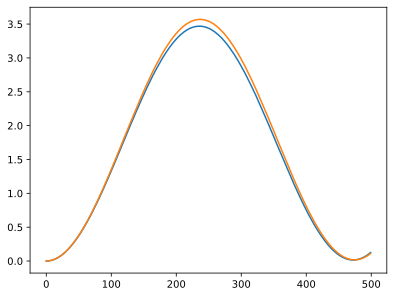

In [8]:
def get_pn_expect(result,a):
    pn_op = jnp.array((a.dag()*a).full())

    # Vectorize the function compute_expectation over the kets
    vectorized_compute_expectation = vmap(compute_expectation, in_axes=(0, None))
    vectorized_compute_expectation = jit(vectorized_compute_expectation)

    if hasattr(result, 'y'):
        states = jnp.array(result.y)  # assuming y contains JAX arrays or density matrices
    elif hasattr(result, 'states'):
        states = jnp.stack([jnp.array(q.full()) for q in result.states])  # assuming states contains QObj or density matrices

    pns_expect = vectorized_compute_expectation(states, pn_op)
    return pns_expect

pn_exp_one = get_pn_expect(results[1],system.a)
pn_exp_two = get_pn_expect(results[2],system.a)

plt.plot(pn_exp_one)
plt.plot(pn_exp_two)

In [9]:
def find_valley_index(values):
    # First, find the index of the peak
    peak_index = 0
    for i in range(1, len(values)):
        if values[i] < values[i - 1]:
            peak_index = i - 1
            break

    # Next, find the minimum value after the peak
    valley_index = peak_index + values[peak_index:].index(min(values[peak_index:]))

    return valley_index

index_of_valley_1 = find_valley_index(list(pn_exp_one))
index_of_valley_2 = find_valley_index(list(pn_exp_two))
index_of_valley_1, index_of_valley_2

(472, 474)

 /Users/jiakaiwang/opt/miniconda3/envs/tensorflow/lib/python3.10/site-packages/jax/_src/array.py: 343

(0.0, 0.1)

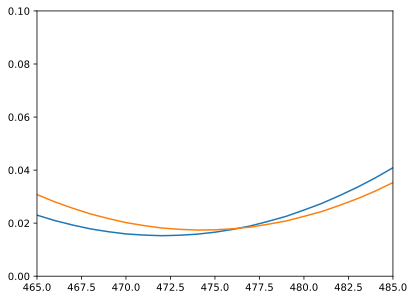

In [14]:
plt.plot(pn_exp_one)
plt.plot(pn_exp_two)
plt.xlim(465,485)
plt.ylim(0,0.1)

# tot_time = 474